In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from wassa_functions import allen_reconstruction_comparison
from dataset_generation import kfold_dataset, make_allen_dataset
from wassa_plots import make_violin, plot_results
from wassa_metrics import WassDist
from wassa_training import get_training_parameters, learn_motifs
import matplotlib.pyplot as plt
import scipy, torch, glob
import numpy as np
from wassa import WassA
from tqdm.notebook import tqdm

In [3]:
dataset_name = 'allen_data_by_image'
device = 'cpu'
dataset_path = '../../'+dataset_name+'/*'
saving_path = '../results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [4]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [5]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [6]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [7]:

frs = False
training_parameters = training_parameters_emd

mse_loss = torch.nn.MSELoss(reduction='none')
emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

all_trainsets, all_testsets, all_othersets = make_allen_dataset(dataset_path, device=device)
ind = torch.randint(len(all_trainsets),[1]).item()

if frs:
    training_set, testing_set, othersets = all_trainsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_testsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_othersets[ind].mean(dim=-1).unsqueeze(-1).to(device)
else:
    training_set, testing_set, othersets = all_trainsets[ind].to(device), all_testsets[ind].to(device), all_othersets[ind].to(device)

num_samples, num_neurons, num_timesteps = training_set.shape
training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
model = WassA(training_parameters,device=device)
model_name = saving_path+dataset_name+str(ind)+get_training_parameters(training_parameters)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None)
if training_parameters['normalize_input']:
    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
factors_testing, testingset_hat = model(testing_set)
factors_others, otherset_hat = model(othersets)
mse_losses_id  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
emd_losses_id  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
mse_losses_ood  = mse_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
emd_losses_ood  = emd_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
print(mse_losses_id, mse_losses_ood, emd_losses_id, emd_losses_ood)

../results/wassa_allen_allen_data_by_image21421190250emdemd likeFalse220000.01None0NoneFalseflatTrue00
tensor([0.0011, 0.0011]) tensor([0.0077, 0.0076]) tensor([0.1899, 0.1753]) tensor([0.1986, 0.2350])


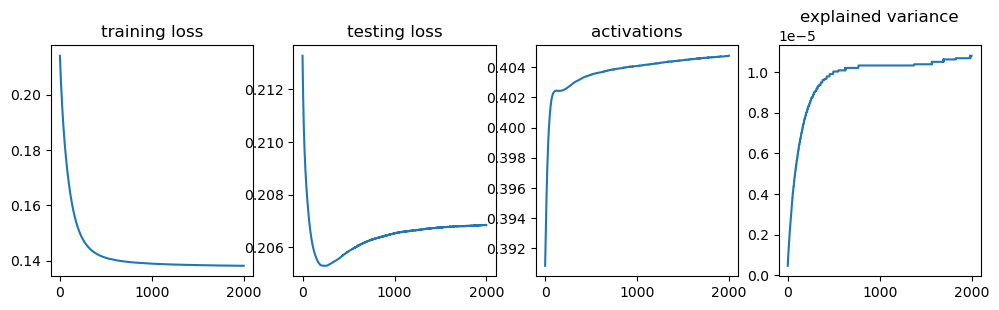

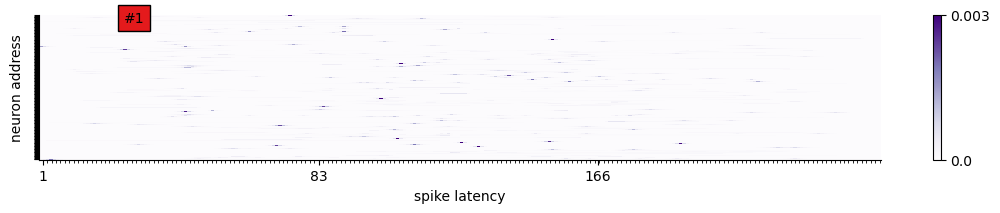

In [8]:
plot_results(training_metrics, metric_names, model, training_set[0], model=None, spike_times = None)

In [10]:
def classifier(dataset_name, training_parameters, metric_names, frs=False, shuffle_spikes=False, saving_path = 'results/allen_',device='cpu'):

    mse_loss = torch.nn.MSELoss(reduction='none')
    emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

    dataset_path = '../../'+dataset_name+'/*'

    all_trainsets, _, _ = make_allen_dataset(dataset_path, device=device)
    number_epochs, number_animals, number_images, number_repetitions = 8, 32, 20, 10
    all_mse, all_emd = torch.zeros([number_epochs,number_animals,number_images,number_images*2]), torch.zeros([number_epochs,number_animals,number_images,number_images*2])
    all_weights = []
    
    dec_score_emd, dec_score_mse = [], []
    fold = 0
    for n_epoch in range(1,8):
        all_testsets, labels = make_allen_testsets_for_decoding(dataset_path,fold_ind=fold,shuffle_spikes=shuffle_spikes,device=device)
        all_weights_fold = []
        for ind_animal in tqdm(range(number_animals)):
    
            ind_images = labels[ind_animal]
    
            if frs:
                testing_set = all_testsets[ind_animal].mean(dim=-1).unsqueeze(-1)
            else:
                testing_set = all_testsets[ind_animal]
    
            mse_losses, emd_losses, corr = torch.zeros([20,40]), torch.zeros([20,40]), torch.zeros([20,40])
    
            num_samples, num_neurons, num_timesteps = testing_set.shape
            training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
            weights_animal = torch.zeros([number_images,num_neurons,num_timesteps])
            for image in range(number_images):
                ind_trainset = int(ind_animal*100+image*5+fold)
                if frs:
                    training_set = all_trainsets[ind_trainset][:n_epoch].mean(dim=-1).unsqueeze(-1)
                else:
                    training_set = all_trainsets[ind_trainset][:n_epoch]

                model = WassA(training_parameters,device=device)
                model_name = saving_path+dataset_name+str(ind_trainset)+str(n_epoch)+get_training_parameters(training_parameters)
                model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None,verbose=False)
                if training_parameters['normalize_input']:
                    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
                factors_testing, testingset_hat = model(testing_set)
            
                mse_losses[image]  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
                emd_losses[image]  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()

                weights_animal[image] = model.weights.data[0]
    
            all_mse[n_epoch,ind_animal] = mse_losses
            all_emd[n_epoch,ind_animal] = emd_losses
            all_weights_fold += [weights_animal]
        all_weights += [all_weights_fold]

        #dec_score_emd.append(compute_decoding_score(all_emd[fold*number_animals:(fold+1)*number_animals]))
        #dec_score_mse.append(compute_decoding_score(all_mse[fold*number_animals:(fold+1)*number_animals]))
        #print(f'percentage correct for EMD decoding: {dec_score_emd[fold].mean()} +- {dec_score_emd[fold].std()}')
        #print(f'percentage correct for MSE decoding: {dec_score_mse[fold].mean()} +- {dec_score_mse[fold].std()}')
    
    return all_mse, all_emd, all_weights

In [11]:
def shuffle_spikes_random(spikes, dim=-1):
    """
    Randomly shuffle spikes along the time axis independently for each trial and neuron.
    spikes: (S x N x T) binary tensor of spike trains
    """
    S, N, T = spikes.shape
    shuffled = torch.zeros_like(spikes)

    for s in range(S):
        for n in range(N):
            # get indices of all time bins
            perm = torch.randperm(T)
            shuffled[s, n] = spikes[s, n, perm]

    return shuffled

def make_allen_testsets_for_decoding(dataset_path, number_samples_per_image=10, number_folds=5, fold_ind = 0, shuffle_spikes = False, swith_test_train = False, device='cpu'):
    
    files_list = glob.glob(dataset_path)
    number_animals = len(files_list)
    all_trainsets, all_testsets = [], []
    id_image_by_animal = []

    for f in range(len(files_list)):
        data = torch.load(files_list[f], weights_only = True)
        data = data.to(torch.float32).to(device)
        if shuffle_spikes:
            data = shuffle_spikes_random(data.clone())
        number_samples, number_neurons, number_timesteps = data.shape
        number_images = number_samples//number_samples_per_image
        id_image, testsets_animal = [], []
        for image in range(number_images):
            trainsets, testsets, indices = kfold_dataset(data[image*number_samples_per_image:(image+1)*number_samples_per_image],k=number_folds)
            if swith_test_train:
                testsets_animal += trainsets[fold_ind].unsqueeze(0)
            else:
                testsets_animal += testsets[fold_ind].unsqueeze(0)
            id_image += [image]*testsets[fold_ind].shape[0]
        id_image_by_animal += [id_image]
        all_testsets += [torch.cat(testsets_animal)]
            
    return all_testsets, id_image_by_animal

In [12]:
all_mse_emd, all_emd_emd, weights_emd = classifier(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
all_mse_mse, all_emd_mse, weights_mse = classifier(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
all_results = [all_mse_mse,all_emd_mse,all_mse_emd,all_emd_emd]
labels = ['MSE-trained/MSE decoding','MSE-trained/EMD decoding','EMD-trained/MSE decoding','EMD-trained/EMD decoding']
colors = ['green','orange','red','blue']
for ind, results in enumerate(all_results):
    
    acc = decoding_accuracy(results)
    number_epochs = acc.shape[0]
    mean =  acc.mean(axis=1)
    std = acc.std(axis=1)
    bottom = mean - std
    top = mean + std
    plt.plot(torch.arange(1,number_epochs+1), mean, 'P', color=colors[ind], markeredgecolor='white', markersize=10, label=labels[ind])
    plt.fill_between(torch.arange(1,number_epochs+1), bottom, top, facecolor=colors[ind], edgecolor=None, alpha=.3)
plt.hlines(.05,0,number_epochs,color='black',linestyles='dashed',label='chance')
plt.legend()
plt.xlabel('number of samples in the training set')
plt.ylabel('decoding accuracy')

In [ ]:
fig.savefig('../figures/allen_decoding_n_epochs.pdf', bbox_inches = 'tight')

In [ ]:
all_results = [all_emd_emd]#,all_emd_mse,all_mse_emd,all_emd_emd]
labels = ['MSE-trained/MSE decoding','MSE-trained/EMD decoding','EMD-trained/MSE decoding','EMD-trained/EMD decoding']
colors = ['green','orange','red','blue']
for ind, results in enumerate(all_results):
    
    acc = decoding_accuracy(results)
    number_epochs = acc.shape[0]
    mean =  acc#.mean(axis=1)
    #std = acc.std(axis=1)
    #bottom = mean - std
    #top = mean + std
    for i in range(mean.shape[1]):
        plt.plot(torch.arange(1,number_epochs+1), mean[:,i]) #, 'P', color=colors[ind], markeredgecolor='white', markersize=10, label=labels[ind])
    #plt.fill_between(torch.arange(1,number_epochs+1), bottom, top, facecolor=colors[ind], edgecolor=None, alpha=.3)
plt.hlines(.05,0,number_epochs,color='black',linestyles='dashed',label='chance')
plt.legend()
plt.xlabel('number of samples in the training set')
plt.ylabel('decoding accuracy')

In [ ]:
all_results = [all_mse_mse]#,all_emd_mse,all_mse_emd,all_emd_emd]
labels = ['MSE-trained/MSE decoding','MSE-trained/EMD decoding','EMD-trained/MSE decoding','EMD-trained/EMD decoding']
colors = ['green','orange','red','blue']
for ind, results in enumerate(all_results):
    
    acc = decoding_accuracy(results)
    number_epochs = acc.shape[0]
    mean =  acc#.mean(axis=1)
    #std = acc.std(axis=1)
    #bottom = mean - std
    #top = mean + std
    for i in range(mean.shape[1]):
        plt.plot(torch.arange(1,number_epochs+1), mean[:,i]) #, 'P', color=colors[ind], markeredgecolor='white', markersize=10, label=labels[ind])
    #plt.fill_between(torch.arange(1,number_epochs+1), bottom, top, facecolor=colors[ind], edgecolor=None, alpha=.3)
plt.hlines(.05,0,number_epochs,color='black',linestyles='dashed',label='chance')
plt.legend()
plt.xlabel('number of samples in the training set')
plt.ylabel('decoding accuracy')